# SubwayQuest — Neighborhood Boundary Explorer

Explore the NTA-verified station-to-neighborhood mapping, see split/merge candidates,
and decide the final neighborhood list for your quest content.

**Before running:** put `complex_to_neighborhood.json` in the same folder as this notebook
(or update `DATA_PATH` below).


In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../processed/complex_to_neighborhood.json"

with open(DATA_PATH) as f:
    raw = json.load(f)

df = pd.DataFrame(raw.values())
df = df.sort_values(["borough", "neighborhood", "name"]).reset_index(drop=True)
print(f"{len(df)} station complexes loaded across {df['borough'].nunique()} boroughs")
df.head()


445 station complexes loaded across 5 boroughs


,complex_id,name,borough,nta_code,neighborhood,neighborhood_borough,lat,lon
0,423,Allerton Av,Bronx,BX1104,Allerton,Bronx,40.865462,-73.867352
1,211,Bedford Park Blvd,Bronx,BX0702,Bedford Park,Bronx,40.873244,-73.887138
2,380,Bedford Park Blvd-Lehman College,Bronx,BX0702,Bedford Park,Bronx,40.873412,-73.890064
3,212,Kingsbridge Rd,Bronx,BX0702,Bedford Park,Bronx,40.866978,-73.893509
4,381,Kingsbridge Rd,Bronx,BX0702,Bedford Park,Bronx,40.867760,-73.897174


## 1. Counts per neighborhood

Sanity check the shape of the data before deciding anything. Sort by count to see
the smallest (quick "visit both" quests) and largest (checklist-style quests) at a glance.


In [12]:
counts = (
    df.groupby(["borough", "neighborhood"])
      .size()
      .reset_index(name="station_count")
      .sort_values(["borough", "station_count"], ascending=[True, False])
)

for boro in counts["borough"].unique():
    print(f"\n=== {boro} ({counts[counts.borough==boro].shape[0]} neighborhoods) ===")
    display(counts[counts.borough == boro].reset_index(drop=True))



=== Bronx (25 neighborhoods) ===


,borough,neighborhood,station_count
0,Bronx,Longwood,6
1,Bronx,Mott Haven-Port Morris,6
2,Bronx,Bedford Park,4
3,Bronx,Williamsbridge-Olinville,4
4,Bronx,Concourse-Concourse Village,3
5,Bronx,Fordham Heights,3
6,Bronx,Kingsbridge-Marble Hill,3
7,Bronx,Melrose,3
8,Bronx,Mount Eden-Claremont (West),3
9,Bronx,Norwood,3



=== Brooklyn (47 neighborhoods) ===


,borough,neighborhood,station_count
0,Brooklyn,Bensonhurst,8
1,Brooklyn,Brownsville,7
2,Brooklyn,Downtown Brooklyn-DUMBO-Boerum Hill,7
3,Brooklyn,Bushwick (East),6
4,Brooklyn,East New York (North),6
5,Brooklyn,East Williamsburg,6
6,Brooklyn,Park Slope,6
7,Brooklyn,Sunset Park (West),6
8,Brooklyn,Bedford-Stuyvesant (West),5
9,Brooklyn,Bushwick (West),5



=== Manhattan (32 neighborhoods) ===


,borough,neighborhood,station_count
0,Manhattan,Financial District-Battery Park City,10
1,Manhattan,Midtown South-Flatiron-Union Square,10
2,Manhattan,Midtown-Times Square,10
3,Manhattan,Central Park,6
4,Manhattan,SoHo-Little Italy-Hudson Square,6
5,Manhattan,Upper East Side-Carnegie Hill,6
6,Manhattan,Washington Heights (North),6
7,Manhattan,Chelsea-Hudson Yards,5
8,Manhattan,Harlem (South),5
9,Manhattan,Tribeca-Civic Center,5



=== Queens (27 neighborhoods) ===


,borough,neighborhood,station_count
0,Queens,Jamaica,6
1,Queens,Elmhurst,5
2,Queens,Long Island City-Hunters Point,5
3,Queens,Ridgewood,5
4,Queens,Rockaway Beach-Arverne-Edgemere,5
5,Queens,Ozone Park,4
6,Queens,South Ozone Park,4
7,Queens,Sunnyside,4
8,Queens,Woodside,4
9,Queens,Astoria (Central),3



=== Staten Island (9 neighborhoods) ===


,borough,neighborhood,station_count
0,Staten Island,Annadale-Huguenot-Prince's Bay-Woodrow,4
1,Staten Island,Grasmere-Arrochar-South Beach-Dongan Hills,3
2,Staten Island,New Dorp-Midland Beach,3
3,Staten Island,Tottenville-Charleston,3
4,Staten Island,Great Kills-Eltingville,2
5,Staten Island,Oakwood-Richmondtown,2
6,Staten Island,Tompkinsville-Stapleton-Clifton-Fox Hills,2
7,Staten Island,Rosebank-Shore Acres-Park Hill,1
8,Staten Island,St. George-New Brighton,1


## 2. Small quest candidates (1–2 stations)

These are the "visit both stations" or single-station callouts rather than full checklists.


In [13]:
small = counts[counts.station_count <= 2].sort_values(["borough", "station_count"])
print(f"{len(small)} neighborhoods with 1-2 stations\n")
display(small.reset_index(drop=True))


58 neighborhoods with 1-2 stations



,borough,neighborhood,station_count
0,Bronx,Allerton,1
1,Bronx,Castle Hill-Unionport,1
2,Bronx,Morris Park,1
3,Bronx,Pelham Parkway-Van Nest,1
4,Bronx,University Heights (North)-Fordham,1
5,Bronx,Crotona Park East,2
6,Bronx,Eastchester-Edenwald-Baychester,2
7,Bronx,Mount Hope,2
8,Bronx,Pelham Gardens,2
9,Bronx,University Heights (South)-Morris Heights,2


## 3. See the stations inside any neighborhood

Change `NEIGHBORHOOD` below to inspect exactly which stations/lines fall into it —
useful for spot-checking before you commit to a split or merge.


In [14]:
NEIGHBORHOOD = "Windsor Terrace-South Slope"

subset = df[df["neighborhood"] == NEIGHBORHOOD][["name", "borough", "lat", "lon"]]
display(subset.reset_index(drop=True))


,name,borough,lat,lon
0,15 St-Prospect Park,Brooklyn,40.660365,-73.979493
1,Fort Hamilton Pkwy,Brooklyn,40.650782,-73.975776


## 4. Visualize a borough's neighborhood splits on a map

Plots every station colored by its assigned neighborhood so you can see the splits
spatially instead of just as a list — this is the closest thing to "what would the
quest map actually look like."

Change `BOROUGH` to look at each one in turn.


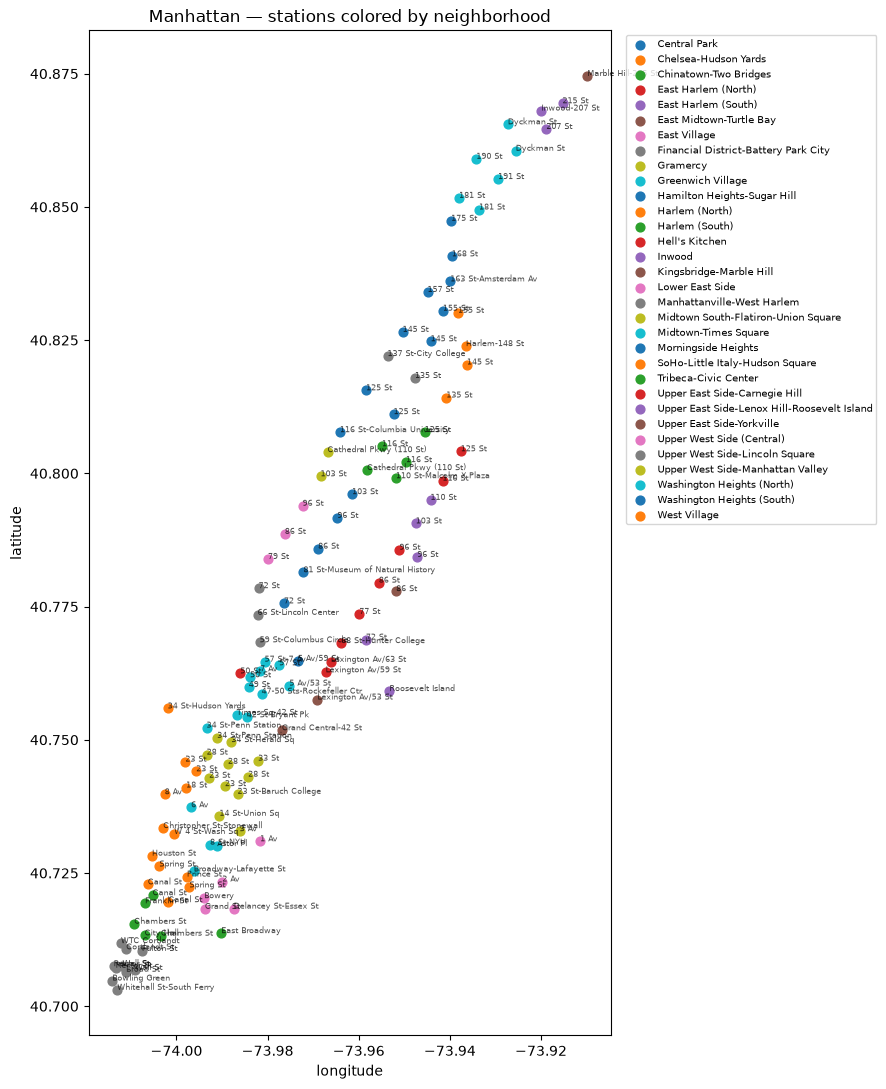

In [15]:
BOROUGH = "Manhattan"

sub = df[df["borough"] == BOROUGH]
fig, ax = plt.subplots(figsize=(9, 11))

for nta, group in sub.groupby("neighborhood"):
    ax.scatter(group["lon"], group["lat"], label=nta, s=40)

for _, row in sub.iterrows():
    ax.annotate(row["name"], (row["lon"], row["lat"]), fontsize=6, alpha=0.7)

ax.set_title(f"{BOROUGH} — stations colored by neighborhood")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()


## 5. Decide merges

DCP's NTA polygons split some colloquial neighborhoods into directional halves
(e.g. `Bushwick (East)` / `Bushwick (West)`). Edit `MERGE_MAP` below to collapse any
of these back into one name for quest purposes. Anything not listed stays as-is.

Pre-filled with the known directional splits found in the current data — delete
entries you'd rather keep split, add any others you spot in the tables/maps above.


In [16]:
MERGE_MAP = {
    "Bushwick (East)": "Bushwick",
    "Bushwick (West)": "Bushwick",
    "Harlem (North)": "Harlem",
    "Harlem (South)": "Harlem",
    "East Harlem (North)": "East Harlem",
    "East Harlem (South)": "East Harlem",
    "Gravesend (East)-Homecrest": "Gravesend",
    "Gravesend (South)": "Gravesend",
    "Gravesend (West)": "Gravesend",
    "Sunset Park (Central)": "Sunset Park",
    "Sunset Park (East)-Borough Park (West)": "Sunset Park",
    "Sunset Park (West)": "Sunset Park",
    "Astoria (Central)": "Astoria",
    "Astoria (East)-Woodside (North)": "Astoria",
    "Astoria (North)-Ditmars-Steinway": "Astoria",
    "Washington Heights (North)": "Washington Heights",
    "Washington Heights (South)": "Washington Heights",
    "Upper West Side (Central)": "Upper West Side",
    "Upper West Side-Lincoln Square": "Upper West Side",
    "Upper West Side-Manhattan Valley": "Upper West Side",
    "Upper East Side-Carnegie Hill": "Upper East Side",
    "Upper East Side-Lenox Hill-Roosevelt Island": "Upper East Side",
    "Upper East Side-Yorkville": "Upper East Side",
}

df["neighborhood_final"] = df["neighborhood"].replace(MERGE_MAP)

before_after = pd.DataFrame({
    "before": [df["neighborhood"].nunique()],
    "after": [df["neighborhood_final"].nunique()],
})
display(before_after)


,before,after
0,139,125


In [17]:
counts_final = (
    df.groupby(["borough", "neighborhood_final"])
      .size()
      .reset_index(name="station_count")
      .sort_values(["borough", "station_count"], ascending=[True, False])
)

for boro in counts_final["borough"].unique():
    print(f"\n=== {boro} ({counts_final[counts_final.borough==boro].shape[0]} neighborhoods after merge) ===")
    display(counts_final[counts_final.borough == boro].reset_index(drop=True))



=== Bronx (25 neighborhoods after merge) ===


,borough,neighborhood_final,station_count
0,Bronx,Longwood,6
1,Bronx,Mott Haven-Port Morris,6
2,Bronx,Bedford Park,4
3,Bronx,Williamsbridge-Olinville,4
4,Bronx,Concourse-Concourse Village,3
5,Bronx,Fordham Heights,3
6,Bronx,Kingsbridge-Marble Hill,3
7,Bronx,Melrose,3
8,Bronx,Mount Eden-Claremont (West),3
9,Bronx,Norwood,3



=== Brooklyn (42 neighborhoods after merge) ===


,borough,neighborhood_final,station_count
0,Brooklyn,Bushwick,11
1,Brooklyn,Gravesend,9
2,Brooklyn,Sunset Park,9
3,Brooklyn,Bensonhurst,8
4,Brooklyn,Brownsville,7
5,Brooklyn,Downtown Brooklyn-DUMBO-Boerum Hill,7
6,Brooklyn,East New York (North),6
7,Brooklyn,East Williamsburg,6
8,Brooklyn,Park Slope,6
9,Brooklyn,Bedford-Stuyvesant (West),5



=== Manhattan (25 neighborhoods after merge) ===


,borough,neighborhood_final,station_count
0,Manhattan,Financial District-Battery Park City,10
1,Manhattan,Midtown South-Flatiron-Union Square,10
2,Manhattan,Midtown-Times Square,10
3,Manhattan,Washington Heights,10
4,Manhattan,Harlem,9
5,Manhattan,Upper East Side,9
6,Manhattan,Upper West Side,8
7,Manhattan,Central Park,6
8,Manhattan,SoHo-Little Italy-Hudson Square,6
9,Manhattan,Chelsea-Hudson Yards,5



=== Queens (25 neighborhoods after merge) ===


,borough,neighborhood_final,station_count
0,Queens,Astoria,7
1,Queens,Jamaica,6
2,Queens,Elmhurst,5
3,Queens,Long Island City-Hunters Point,5
4,Queens,Ridgewood,5
5,Queens,Rockaway Beach-Arverne-Edgemere,5
6,Queens,Ozone Park,4
7,Queens,South Ozone Park,4
8,Queens,Sunnyside,4
9,Queens,Woodside,4



=== Staten Island (9 neighborhoods after merge) ===


,borough,neighborhood_final,station_count
0,Staten Island,Annadale-Huguenot-Prince's Bay-Woodrow,4
1,Staten Island,Grasmere-Arrochar-South Beach-Dongan Hills,3
2,Staten Island,New Dorp-Midland Beach,3
3,Staten Island,Tottenville-Charleston,3
4,Staten Island,Great Kills-Eltingville,2
5,Staten Island,Oakwood-Richmondtown,2
6,Staten Island,Tompkinsville-Stapleton-Clifton-Fox Hills,2
7,Staten Island,Rosebank-Shore Acres-Park Hill,1
8,Staten Island,St. George-New Brighton,1


## 6. Export the final decision

Once the counts above look right, run this to write the final mapping —
this is what feeds `quests_source.json`.


In [18]:
OUTPUT_PATH = "../processed/final_neighborhoods.json"

final = {}
for cid, row in df.set_index("complex_id").iterrows():
    final[str(cid)] = {
        "name": row["name"],
        "borough": row["borough"],
        "neighborhood": row["neighborhood_final"],
        "lat": row["lat"],
        "lon": row["lon"],
    }

with open(OUTPUT_PATH, "w") as f:
    json.dump(final, f, indent=2)

print(f"Wrote {len(final)} stations to {OUTPUT_PATH}")


Wrote 445 stations to ../processed/final_neighborhoods.json
